In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

np.random.seed(40)

#1.1. реализовать функции:
- to_one_hot(Y),
- from_one_hot(Y),
- sum_neuron(x=None, w=None),
- sigmoid_complex_neuron(x = None, w = None, bias=0, lymbd = 1),
- sigmoid_deriv(g),
- normalize(X, axis=-1, order=2)

In [34]:
def to_one_hot(Y):
    Y = np.asarray(Y, dtype=int).flatten()
    return np.eye(np.max(Y) + 1)[Y]

def from_one_hot(Y):
    Y = np.asarray(Y)
    return np.argmax(Y, axis=-1)

def sum_neuron(x=None, w=None):
    return np.dot(x, w)

def sigmoid(g):
    g = np.clip(g, -300, 300)
    return 1 / (1 + np.exp(-g))


def sigmoid_complex_neuron(x=None, w=None, bias=0, lymbd=1):
    g = sum_neuron(x, w) + bias
    return sigmoid(lymbd * g)

def sigmoid_deriv(g):
    return g * (1 - g)

def normalize(X, axis=-1, order=2):
    X = np.asarray(X, dtype=float)
    norm = np.linalg.norm(X, ord=order, axis=axis, keepdims=True)
    norm[norm == 0] = 1
    return X / norm

#1.2. визуализировать результат работы
- sigmoid_complex_neuron(x = None, w = None, bias=0, lymbd = 1),
- sigmoid_deriv(g)

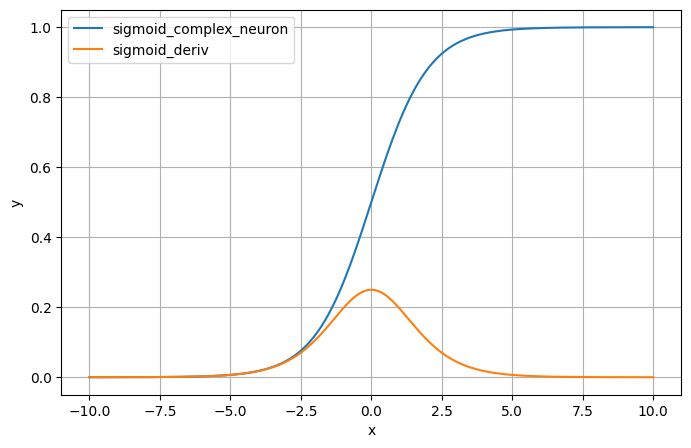

In [35]:
x_values = np.linspace(-10, 10, 200)
w = np.array([1.0])

y_values = np.array([
    sigmoid_complex_neuron(x=np.array([x]), w=w, bias=0, lymbd=1)
    for x in x_values
])

deriv_values = sigmoid_deriv(y_values)

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, label='sigmoid_complex_neuron')
plt.plot(x_values, deriv_values, label='sigmoid_deriv')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()

plt.show()

#2.1. Реализовать цикл работы для обучения модели по оратному распространению ошибки на примере ирисов Фишера

In [36]:
### Шаг 1. Описание модели и данных: число эпох, веса, скорость обучения
neuron_numb = 5
epochs = 10000
n = 0.05

w0 = 2 * np.random.random((4, neuron_numb)) - 1
w1 = 2 * np.random.random((neuron_numb, 3)) - 1

In [37]:
### Шаг 2. Подготовка тренировочных данных
data = load_iris()
# print(data.DESCR)

x = data['data']
print(x.shape)
x = normalize(x)

y = data['target']
print(y.shape)
print(np.unique(y))
y = y.flatten()
y = to_one_hot(y)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=40)

(150, 4)
(150,)
[0 1 2]


In [38]:
### Шаг 3. Обученние нейронной сети

# массив для ошибок, чтобы потом построить график
errors = []

# процесс обучения
for i in range(epochs):
    # прямое распространение(feed forward)
    layer0 = X_train
    z1 = np.dot(layer0, w0)
    layer1 = sigmoid(z1)
    z2 = np.dot(layer1, w1)
    layer2 = sigmoid(z2)
    # оценка ошибки на выходе
    error = y_train - layer2
    errors.append(np.mean(np.abs(error)))

    # получение значения производной активационнной функции текущего слоя
    dE_dlayer2 = layer2 - y_train

    # производная функции активации выходного слоя
    dlayer2_dz2 = sigmoid_deriv(layer2)
    dE_dz2 = dE_dlayer2 * dlayer2_dz2

    # производная ошибки по весам между скрытым и выходным слоями
    dE_dw1 = np.dot(layer1.T, dE_dz2)

    # перенос производной ошибки на скрытый слой
    dE_dlayer1 = np.dot(dE_dz2, w1.T)

    # производная функции активации скрытого слоя
    dlayer1_dz1 = sigmoid_deriv(layer1)
    dE_dz1 = dE_dlayer1 * dlayer1_dz1

    # производная ошибки по весам между входным и скрытым слоями
    dE_dw0 = np.dot(layer0.T, dE_dz1)

    # градиентный спуск
    w1 -= n * dE_dw1
    w0 -= n * dE_dw0

#2.2. визуализировать результаты

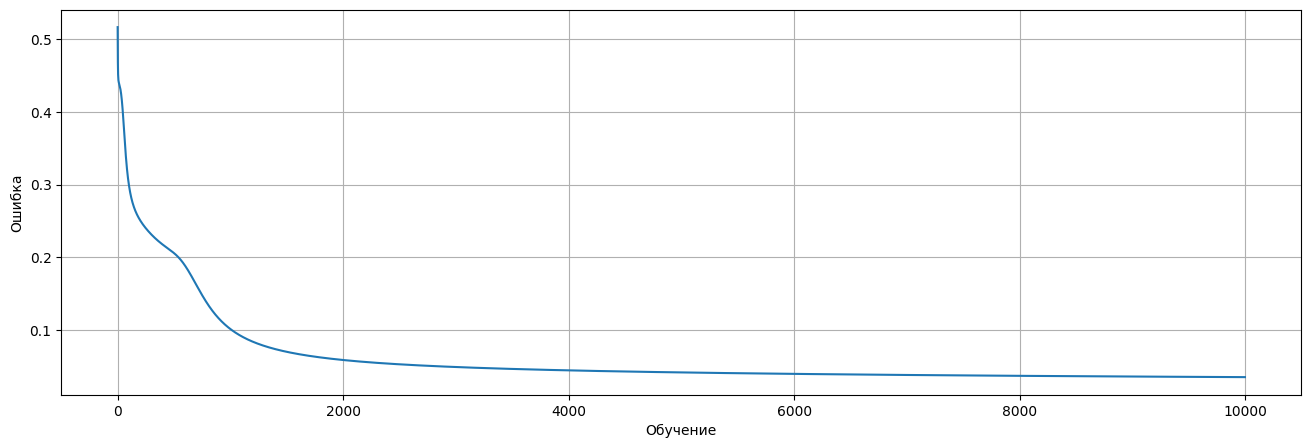

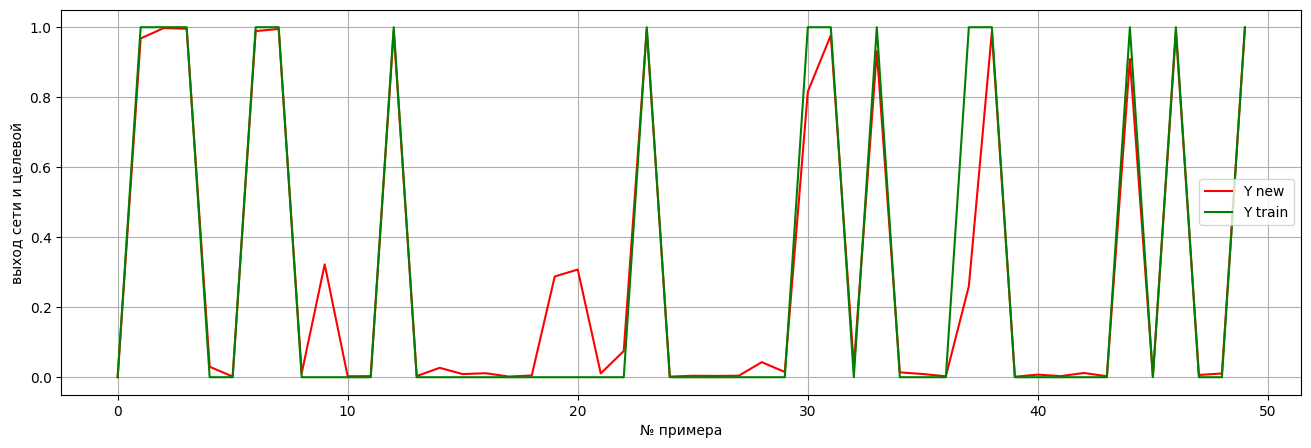

Аккуратность нейронной сети на тренировочных данных:96.48%
Ошибка: 0.03516932220648466


In [39]:
### Шаг 4. Демонстрация полученных результатов

plt.figure(figsize=(16, 5))
plt.plot(errors)
plt.xlabel('Обучение')
plt.ylabel('Ошибка')
plt.grid()
plt.show()

N = 50
plt.figure(figsize=(16, 5))
plt.plot(layer2[:N, 1], 'r', label='Y new')
plt.plot(y_train[:N, 1], 'g', label='Y train')
plt.xlabel('№ примера')
plt.ylabel('выход сети и целевой')
plt.legend()
plt.grid()
plt.show()

error = np.mean(np.abs(layer2_error))
accuracy = (1 - error) * 100
print("Аккуратность нейронной сети на тренировочных данных:" + str(round(accuracy, 2)) + "%")
print("Ошибка:", error)

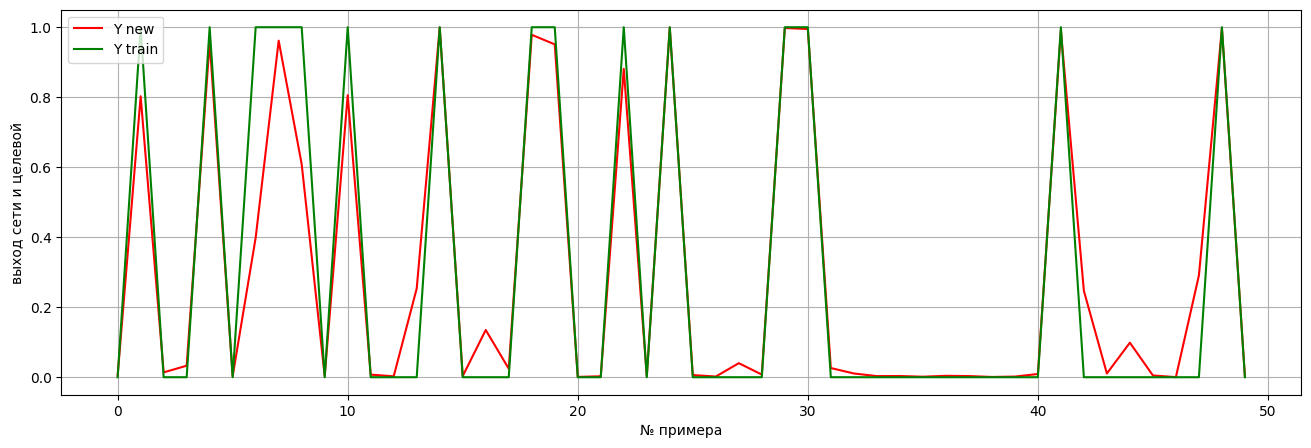

Аккуратность нейронной сети на тестовых данных:96.15%
Ошибка: 0.0385357075986917


In [40]:
# прямое распространение(feed forward)
layer0_t = X_test
layer1_t = sigmoid(np.dot(layer0_t, w0))
layer2_t = sigmoid(np.dot(layer1_t, w1))

# оценка ошибки на выходе
layer2_error_t = y_test - layer2_t

N = 50
plt.figure(figsize = (16,5))
plt.plot(layer2_t[:N,1], 'r',label = 'Y new')
plt.plot(y_test[:N,1],'g', label = 'Y train')
plt.xlabel('№ примера')
plt.ylabel('выход сети и целевой')
plt.grid()
plt.legend( )
plt.show()

# метрика модели
error_t = np.mean(np.abs(layer2_error_t))
accuracy_t = (1 - error_t) * 100
print("Аккуратность нейронной сети на тестовых данных:" + str(round(accuracy_t,2)) + "%")
print("Ошибка:", error_t)

#3. Практическое задание

Используем набор примеров load_digits

In [41]:
data = load_digits()
# print(data.DESCR)

x = data['data']
print(x.shape)
x = normalize(x)

y = data['target']
print(y.shape)
print(np.unique(y))
y = y.flatten()
y = to_one_hot(y)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=40)

(1797, 64)
(1797,)
[0 1 2 3 4 5 6 7 8 9]


#3.1.  Опишите - какой результата получен в нейросети в зависимости от:
  - числа нейронов в слое(для 2-хслойной сети),
  - шага обучения в диапазоне [10.0**(-5), 10.0].
  - фиксируйте для тренировочного и тестового набора метрики accuracy.

In [42]:
epochs = 1000

neuron_values = [5, 10, 20, 50]

learning_rates = [10**-5, 10**-4, 10**-3, 10**-2, 10**-1, 1, 10]

results = []

In [43]:
def train_network(X_train, y_train, neuron_numb, n, epochs):
    w0 = 2 * np.random.random((X_train.shape[1], neuron_numb)) - 1
    w1 = 2 * np.random.random((neuron_numb, y_train.shape[1])) - 1

    errors = []

    for i in range(epochs):

    # Прямой проход
        layer0 = X_train
        z1 = np.dot(layer0, w0)
        layer1 = sigmoid(np.dot(layer0, w0))
        z2 = np.dot(layer1, w1)
        layer2 = sigmoid(z2)

        error = y_train - layer2
        errors.append(np.mean(np.abs(error)))

        dE_dlayer2 = layer2 - y_train

        dlayer2_dz2 = sigmoid_deriv(layer2)

        dE_dz2 = dE_dlayer2 * dlayer2_dz2

        dE_dw1 = np.dot(layer1.T, dE_dz2)

        dE_dlayer1 = np.dot(dE_dz2, w1.T)

        dlayer1_dz1 = sigmoid_deriv(layer1)

        dE_dz1 = dE_dlayer1 * dlayer1_dz1

        dE_dw0 = np.dot(layer0.T, dE_dz1)

        w1 -= n * dE_dw1
        w0 -= n * dE_dw0

    return w0, w1, errors

In [44]:
def get_accuracy(X, y, w0, w1):
    layer1 = sigmoid(np.dot(X, w0))
    layer2 = sigmoid(np.dot(layer1, w1))

    predicted = from_one_hot(layer2)
    correct = from_one_hot(y)

    return np.mean(predicted == correct) * 100

In [45]:
for neuron_numb in neuron_values:
    for n in learning_rates:
        w0, w1, errors = train_network(X_train, y_train, neuron_numb, n, epochs)

        accuracy_train = get_accuracy(X_train, y_train, w0, w1)
        accuracy_test = get_accuracy(X_test, y_test, w0, w1)

        results.append([neuron_numb, n, accuracy_train, accuracy_test])

results_df = pd.DataFrame(
    results,
    columns=[
        'Число нейронов',
        'Шаг обучения',
        'Accuracy train',
        'Accuracy test'
    ]
)

results_df

,Число нейронов,Шаг обучения,Accuracy train,Accuracy test
0,5,0.00001,8.728180,11.279461
1,5,0.00010,23.025769,18.686869
2,5,0.00100,39.733998,37.205387
3,5,0.01000,91.105569,83.838384
4,5,0.10000,75.976725,75.420875
5,5,1.00000,10.141313,9.259259
6,5,10.00000,10.972569,8.417508
7,10,0.00001,7.481297,7.407407
8,10,0.00010,17.456359,14.646465
9,10,0.00100,69.576060,64.814815


#3.2. Сделайте вывод - что помогло вам улучшить качество классификации в нейросети на тестовом наборе?

In [46]:
best_train = results_df.loc[results_df['Accuracy train'].idxmax()]
best_test = results_df.loc[results_df['Accuracy test'].idxmax()]

print("Лучший результат на тренировочном наборе:")
print("Число нейронов:", int(best_train['Число нейронов']))
print("Шаг обучения:", best_train['Шаг обучения'])
print("Accuracy train:", round(best_train['Accuracy train'], 2), "%")

print()

print("Лучший результат на тестовом наборе:")
print("Число нейронов:", int(best_test['Число нейронов']))
print("Шаг обучения:", best_test['Шаг обучения'])
print("Accuracy test:", round(best_test['Accuracy test'], 2), "%")

Лучший результат на тренировочном наборе:
Число нейронов: 20
Шаг обучения: 0.01
Accuracy train: 97.67 %

Лучший результат на тестовом наборе:
Число нейронов: 20
Шаг обучения: 0.01
Accuracy test: 94.95 %


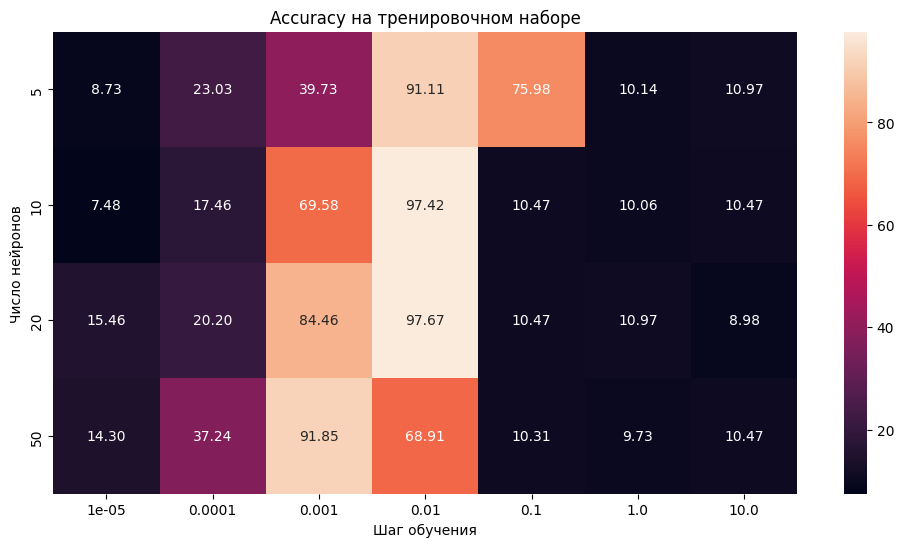

In [47]:
train_heatmap = results_df.pivot(
    index='Число нейронов',
    columns='Шаг обучения',
    values='Accuracy train'
)

plt.figure(figsize=(12, 6))
sns.heatmap(train_heatmap, annot=True, fmt='.2f')

plt.title('Accuracy на тренировочном наборе')
plt.xlabel('Шаг обучения')
plt.ylabel('Число нейронов')
plt.show()

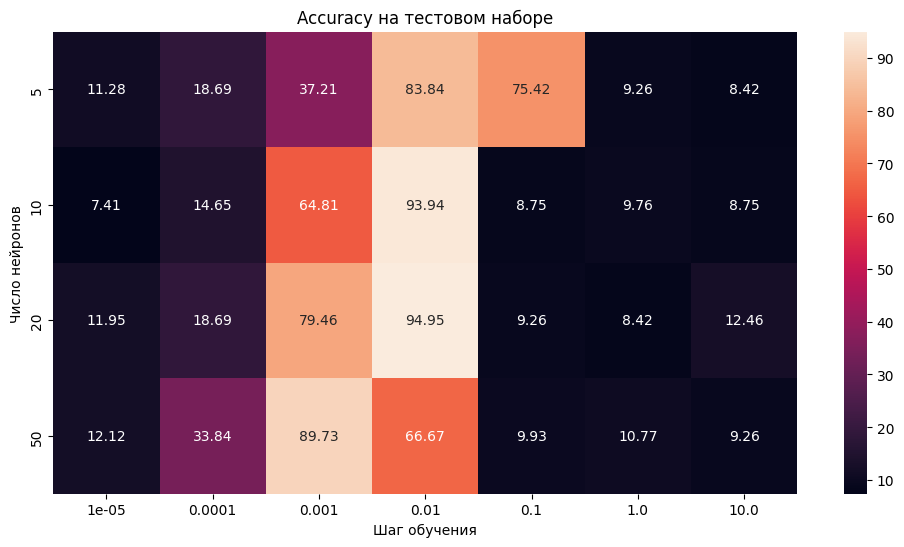

In [48]:
test_heatmap = results_df.pivot(
    index='Число нейронов',
    columns='Шаг обучения',
    values='Accuracy test'
)

plt.figure(figsize=(12, 6))
sns.heatmap(test_heatmap, annot=True, fmt='.2f')

plt.title('Accuracy на тестовом наборе')
plt.xlabel('Шаг обучения')
plt.ylabel('Число нейронов')
plt.show()

### Вывод:

По результатам видно, что качество улучшается не просто по отдельности от числа нерйонов и размера шага обучения, а от правильтного сочетания этих значений

Слишком маленький шаг замедляет обучение, а слишком большой делает его нестабильным. Слишком малое число нейронов ограничивает возможности сети, а слишком большое может усложнять обучение и тем самым ухудшать его

#3.3. Для одного варианта сетей сформируйте матрицу ошибок по классам. Оцените качество модели по каждому классу отдельно (полнота , точность). Сделайте вывод.

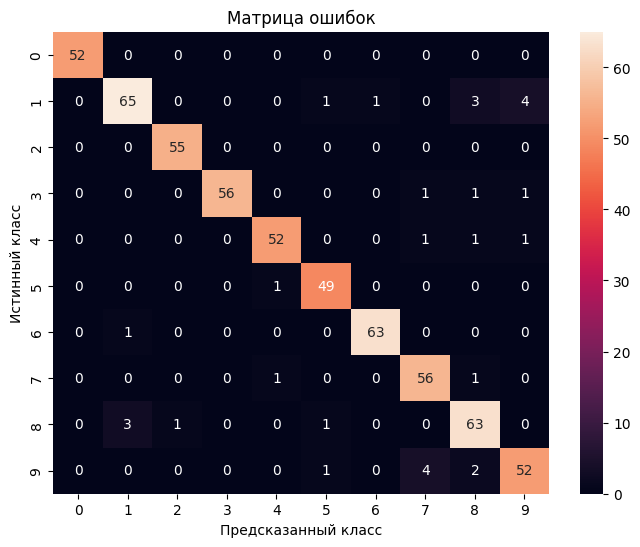

In [49]:
neuron_numb_best = int(best_test['Число нейронов'])
n_best = best_test['Шаг обучения']

w0, w1, errors = train_network(X_train, y_train, neuron_numb_best, n_best, epochs)

layer1 = sigmoid(np.dot(X_test, w0))
layer2 = sigmoid(np.dot(layer1, w1))

predicted = from_one_hot(layer2)
correct = from_one_hot(y_test)

cm = confusion_matrix(correct, predicted)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

In [50]:
precision = precision_score(correct, predicted, average=None, zero_division=0)
recall = recall_score(correct, predicted, average=None, zero_division=0)

metrics_df = pd.DataFrame({
    'Класс': range(len(precision)),
    'Точность': precision,
    'Полнота': recall
})

metrics_df

,Класс,Точность,Полнота
0,0,1.000000,1.000000
1,1,0.942029,0.878378
2,2,0.982143,1.000000
3,3,1.000000,0.949153
4,4,0.962963,0.945455
5,5,0.942308,0.980000
6,6,0.984375,0.984375
7,7,0.903226,0.965517
8,8,0.887324,0.926471
9,9,0.896552,0.881356


In [51]:
accuracy = np.mean(predicted == correct) * 100

print("Accuracy сети:", round(accuracy, 2), "%")
print("Класс с минимальной точностью:", np.argmin(precision))
print("Класс с минимальной полнотой:", np.argmin(recall))

Accuracy сети: 94.78 %
Класс с минимальной точностью: 8
Класс с минимальной полнотой: 1


### Вывод:
Матрица ошибок показывает, что основная часть значений сосредоточена на главноой дигонали, а значит большинство объектов классифицировано правильно. Основные ошибки приходятся на отдельные похожие между собой классы.

Значения точности и полноты остаются высокими, а значит модель обладает хорошим качеством распознавания
